# Baseline
Ansatz:
- Übersicht der Multi-view Pig Posture Recognition Challenge
- Datenanalyse und -vorverarbeitung
- Baseline Modellierung für zukunfitge Optimierungen

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

<jemalloc>: Unsupported system page size


Using device: cuda:3


## Datenanalyse

In [2]:
data_dir = "/datasets/multi-view-pig-posture-recognition/"
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
dir_train2 = os.path.join(data_dir, "train2_images")

test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
dir_test = os.path.join(data_dir, "test_images")

print(f"Train2: {len(train2_df)} samples")
print(train2_df.head())
print(f"\nKlassenverteilung:")
print(train2_df["class_id"].value_counts().sort_index())

Train2: 23450 samples
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   
2  train_pen1_orb_cam1_20250108_085204_0002   
3  train_pen1_orb_cam1_20250108_085204_0003   
4  train_pen1_orb_cam1_20250108_085204_0004   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
2  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
3  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
4  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  
2   [732.0,137.5,342.0,198.0]         1  
3   [830.0,169.0,370.0,263.0]         0  
4   [611.5,314.8,381.5,386.6]         3  

Klassenverteilung:
class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64


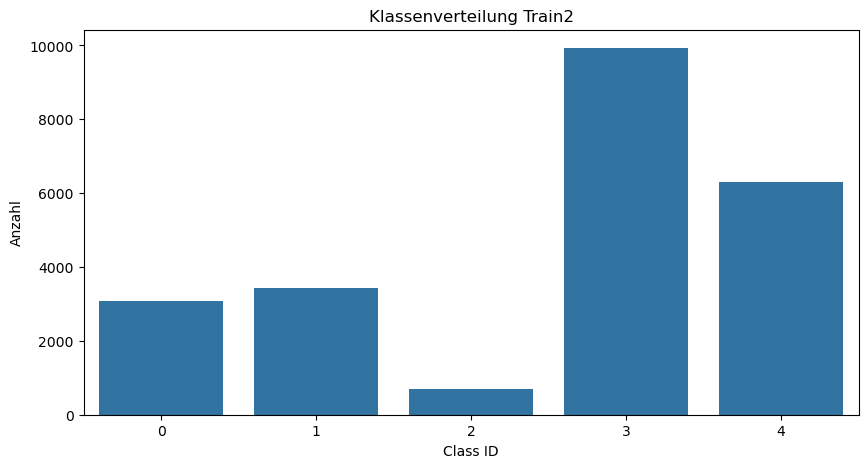

In [3]:
def parse_bbox_safe(x):
    if isinstance(x, str):
        return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x

train2_df["bbox"] = train2_df["bbox"].apply(parse_bbox_safe)

# Klassenverteilung
class_counts = train2_df["class_id"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Klassenverteilung Train2")
plt.xlabel("Class ID")
plt.ylabel("Anzahl")
plt.show()

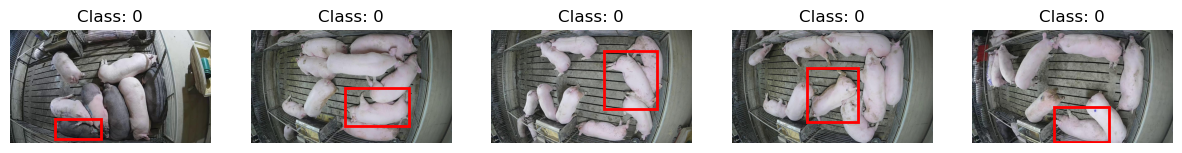

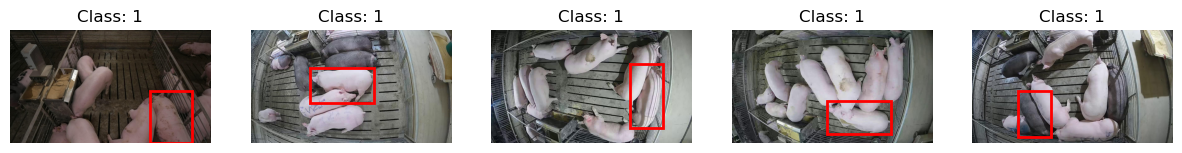

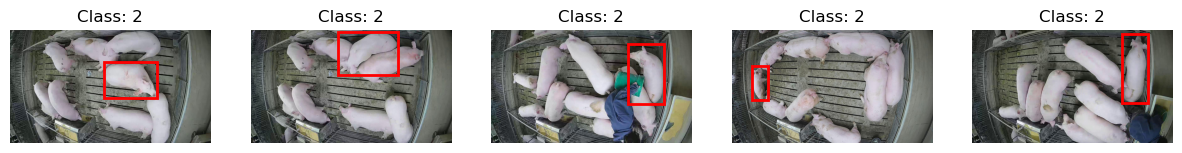

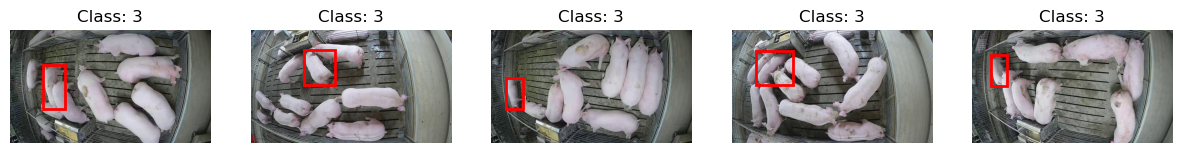

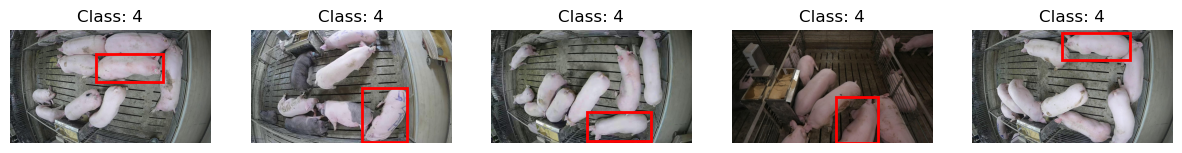

In [4]:
def show_grid_per_class(df, img_dir, class_id, num_images=5):
    subset = df[df["class_id"] == class_id].sample(n=num_images, replace=True)
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        bbox = row["bbox"]
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.axis("off")
        plt.title(f"Class: {class_id}")
    plt.show()

for c in sorted(train2_df["class_id"].unique()):
    show_grid_per_class(train2_df, dir_train2, c)

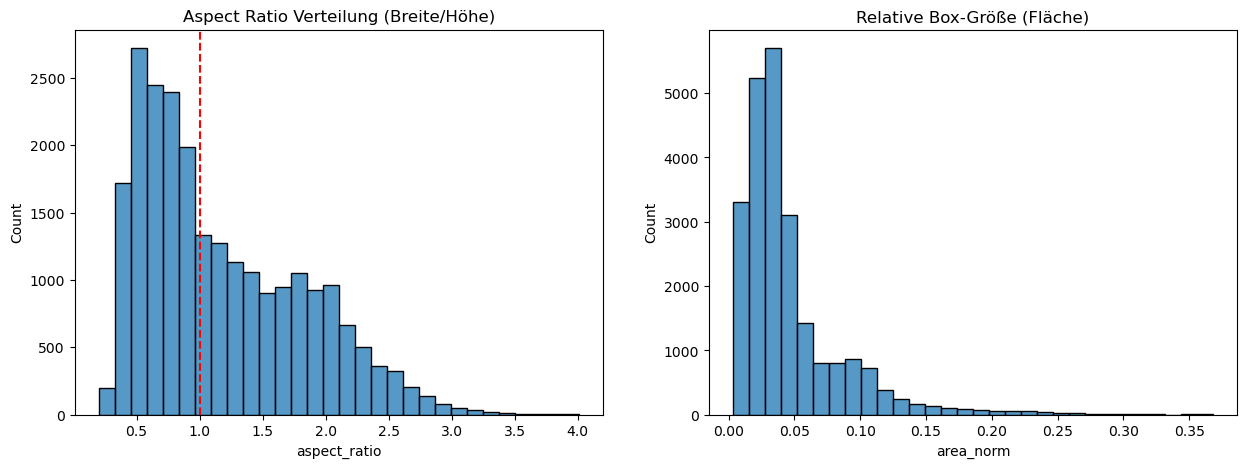

In [5]:
train2_df["bbox"] = train2_df["bbox"].apply(parse_bbox_safe)

bbox_data = train2_df["bbox"].tolist()
bbox_stats = pd.DataFrame(bbox_data, columns=["x", "y", "w", "h"])

bbox_stats["aspect_ratio"] = bbox_stats["w"] / bbox_stats["h"]
bbox_stats["area_norm"] = (bbox_stats["w"] * bbox_stats["h"]) / (1920 * 1080)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(bbox_stats["aspect_ratio"], bins=30, ax=ax[0])
ax[0].set_title("Aspect Ratio Verteilung (Breite/Höhe)")
ax[0].axvline(1, color="red", linestyle="--")

sns.histplot(bbox_stats["area_norm"], bins=30, ax=ax[1])
ax[1].set_title("Relative Box-Größe (Fläche)")
plt.show()

In [6]:
class PigPostureDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["class_id"]

        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = [float(x) for x in bbox.replace("[", "").replace("]", "").split(",")]
        x, y, w, h = bbox
        img_w, img_h = image.size
        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(img_w, int(x + w))
        y2 = min(img_h, int(y + h))
        image = image.crop((x1, y1, x2, y2))

        if self.transform:
            image = self.transform(image)

        return image, label

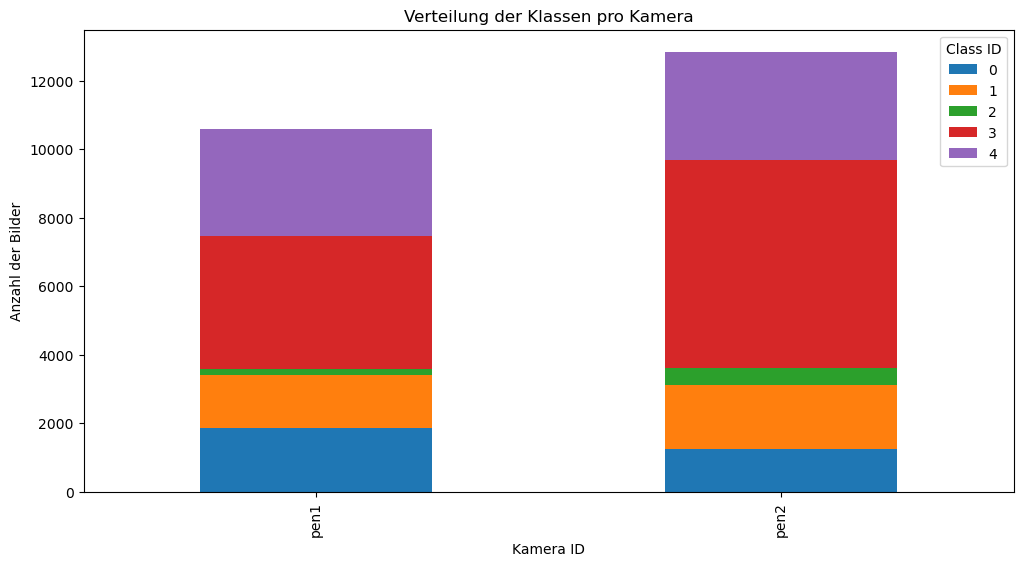

In [7]:
train2_df["camera_id"] = train2_df["image_id"].apply(lambda x: x.split("_")[0])
camera_class_counts = (
    train2_df.groupby(["camera_id", "class_id"]).size().unstack(fill_value=0)
)
plt.figure(figsize=(12, 6))
camera_class_counts.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Verteilung der Klassen pro Kamera")
plt.xlabel("Kamera ID")
plt.ylabel("Anzahl der Bilder")
plt.legend(title="Class ID")
plt.show()

# Model


In [8]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_split_df, val_split_df = train_test_split(
    train2_df, test_size=0.2, random_state=42, stratify=train2_df["class_id"]
)

print(f"Train: {len(train_split_df)} samples")
print(f"Val:   {len(val_split_df)} samples")

train_dataset = PigPostureDataset(train_split_df, dir_train2, transform=transform_train)
val_dataset = PigPostureDataset(val_split_df, dir_train2, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Train: 18760 samples
Val:   4690 samples


In [9]:
class PigPostureModel(nn.Module):
    def __init__(self, num_classes=5):
        super(PigPostureModel, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for param in self.backbone.parameters():
            param.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def unfreeze_last_layers(self, num_layers=2):
        layers = [
            self.backbone.layer1,
            self.backbone.layer2,
            self.backbone.layer3,
            self.backbone.layer4,
        ]
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"Unfroze last {num_layers} backbone layers for fine-tuning.")

    def forward(self, x):
        return self.backbone(x)

model = PigPostureModel(num_classes=5)

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=10, save_name="best_model_T2.pth"):
    model.to(device)
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    best_val_f1 = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_labels, all_preds = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        epoch_val_f1 = f1_score(all_labels, all_preds, average="macro")
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        if scheduler:
            scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.4f} | "
              f"Macro F1: {epoch_val_f1:.4f}")

        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            torch.save(model.state_dict(), save_name)
            print(f"  -> Neues bestes Modell gespeichert! (Macro F1: {best_val_f1:.4f})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(range(1, num_epochs + 1), train_loss_history, marker="o", label="Train Loss")
    axes[0].plot(range(1, num_epochs + 1), val_loss_history, marker="s", label="Val Loss")
    axes[0].set_title("Loss über Epochen")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(range(1, num_epochs + 1), val_acc_history, marker="o", color="green")
    axes[1].set_title("Validation Accuracy über Epochen")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.show()
    print(f"\nBeste Validation Accuracy: {best_val_f1:.4f}")

=== Phase 1: Training Classifier Head (T2) ===


Epoch 1/1 [Val]: 100%|██████████| 147/147 [00:27<00:00,  5.42it/s]


Epoch 1/1 | Train Loss: 0.8536 | Val Loss: 0.7223 | Val Acc: 0.7309 | Macro F1: 0.5612
  -> Neues bestes Modell gespeichert! (Macro F1: 0.5612)


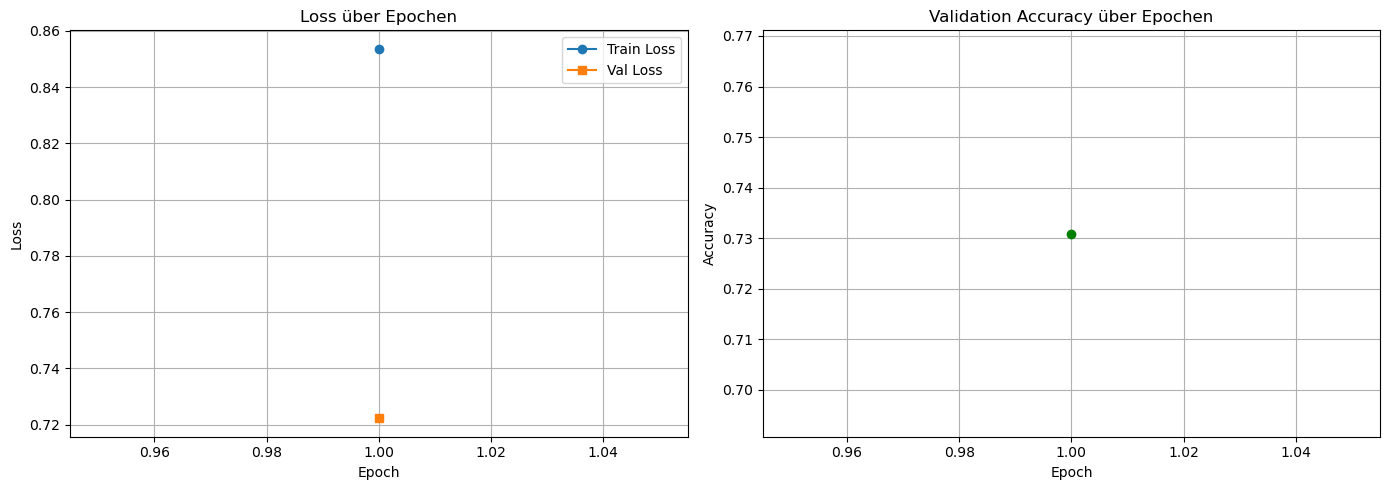


Beste Validation Accuracy: 0.5612


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.backbone.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

print("=== Phase 1: Training Classifier Head (T2) ===")
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=1, save_name="best_model_T2.pth")

Unfroze last 2 backbone layers for fine-tuning.
=== Phase 2: Fine-Tuning Last Backbone Layers (T2) ===


Epoch 1/1 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.67it/s]


Epoch 1/1 | Train Loss: 0.6539 | Val Loss: 0.5551 | Val Acc: 0.7921 | Macro F1: 0.6330
  -> Neues bestes Modell gespeichert! (Macro F1: 0.6330)


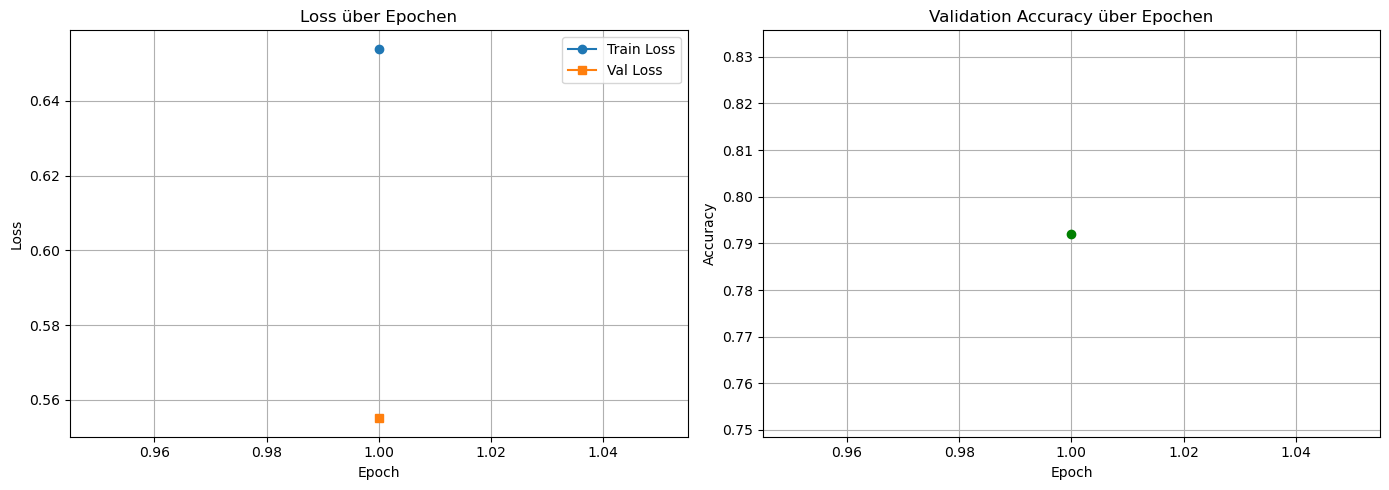


Beste Validation Accuracy: 0.6330


In [13]:
model.unfreeze_last_layers(num_layers=2)

optimizer_ft = torch.optim.Adam([
    {"params": model.backbone.layer3.parameters(), "lr": 1e-5},
    {"params": model.backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model.backbone.fc.parameters(), "lr": 1e-4},
])
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", patience=3, factor=0.5)

print("=== Phase 2: Fine-Tuning Last Backbone Layers (T2) ===")
train_model(model, train_loader, val_loader, criterion, optimizer_ft, scheduler_ft, num_epochs=1, save_name="best_model_T2.pth")

=== Evaluation auf Validation Set (T2) ===


Evaluating: 100%|██████████| 147/147 [00:25<00:00,  5.67it/s]



Accuracy: 0.7921


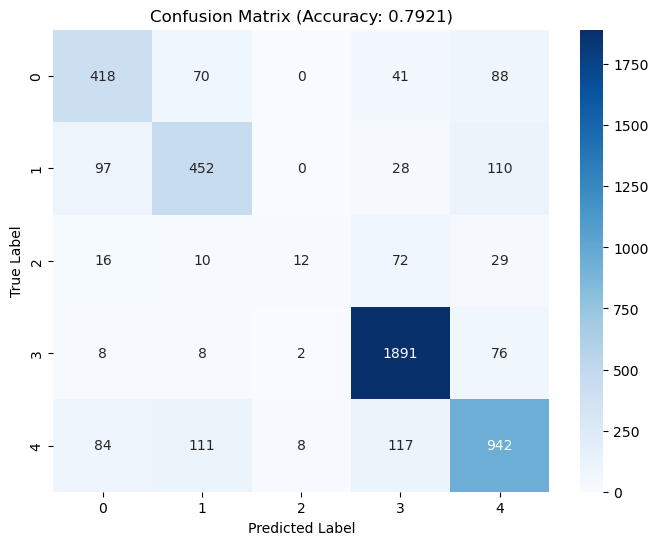

0.7921108742004265

In [14]:
model.load_state_dict(torch.load("best_model_T2.pth"))

def evaluate_model(model, dataloader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total
    print(f"\nAccuracy: {accuracy:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=range(5), yticklabels=range(5))
    plt.title(f"Confusion Matrix (Accuracy: {accuracy:.4f})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return accuracy

print("=== Evaluation auf Validation Set (T2) ===")
evaluate_model(model, val_loader)